# IS 346: Data Quality - Project
**Prepared by:** Alanoud Alotaibi 445202172 , Najd Altamimi 444201287

**Supervise by:** Dr.Nouf Aldrees

**loading dataset and libraries**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. Load dataset
path = kagglehub.dataset_download("nudratabbas/messy-clinic-appointments-dataset")
file_path = os.path.join(path, 'messy_clinic_appointments.csv')
df = pd.read_csv(file_path)

# 2. Dataset Description
print("DATASET DESCRIPTION")
print("="*50)
desc = """
Attribute            | Description
patient_id           | Unique patient identifier
patient_name         | Full name of the patient
age                  | Age of the patient
gender               | Gender (Male/Female)
appointment_date     | Intended appointment date (dd/mm/yyyy)
booking_date         | Date the appointment was booked
doctor               | Assigned doctor name
department           | Medical department
billing_amount       | Consultation fee (should be numeric)
follow_up_required   | Whether follow-up is needed (Yes/No)
"""
print(desc)


C:\Users\ala11\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DATASET DESCRIPTION

Attribute            | Description
patient_id           | Unique patient identifier
patient_name         | Full name of the patient
age                  | Age of the patient
gender               | Gender (Male/Female)
appointment_date     | Intended appointment date (dd/mm/yyyy)
booking_date         | Date the appointment was booked
doctor               | Assigned doctor name
department           | Medical department
billing_amount       | Consultation fee (should be numeric)
follow_up_required   | Whether follow-up is needed (Yes/No)



**Data Profiling**

DATA PROFILING

--- Dataset Shape & Columns ---
Columns in dataset: ['patient_id', 'patient_name', 'age', 'gender', 'appointment_date', 'booking_date', 'doctor', 'department', 'billing_amount', 'follow_up_required']
The Dataset has 10 attributes, 1000 instances.
Shape: 1000 rows × 10 columns

--- Descriptive Statistics (All Columns) ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,1000.0,NaN,NaN,NaN,1050.521,28.888581,1000.0,1025.0,1051.0,1075.0,1100.0
patient_name,1000,988,Regina Wilson,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,53.75,21.137604,18.0,34.0,55.0,71.0,90.0
gender,950,8,0,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,1000,735,2026/02/11,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,1000,822,"August 05, 24",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doctor,1000,990,Jennifer Adams,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,1000,4,Neurology,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_amount,950,949,€243.78,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
follow_up_required,1000,6,0,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Descriptive Statistics (Numeric Columns Only) ---


,patient_id,age
count,1000.000000,1000.000000
mean,1050.521000,53.750000
std,28.888581,21.137604
min,1000.000000,18.000000
25%,1025.000000,34.000000
50%,1051.000000,55.000000
75%,1075.000000,71.000000
max,1100.000000,90.000000



--- Missing Values Details ---


,Column,Missing Count,% Missing
8,billing_amount,50,5.0
3,gender,50,5.0


Missing values summary (only columns with missing data):
gender            50
billing_amount    50
dtype: int64

--- Duplicates ---
Exact duplicate rows: 0
Duplicate patient IDs: 899
Total fully duplicated rows in the dataset: 0
Total duplicate Patient IDs: 899 (important to not have duplicate in ID)

--- Validity & Inconsistency Issues ---
Gender errors (not strictly Male/Female): 707
Total Gender errors (violates strict 'Male'/'Female' standard): 707
Billing amount non-numeric: 950
Total invalid Billing Amounts (contains text/symbols): 950
Age out of 0-120: 0
Appointment date format errors: 908, future dates: 13

--- gender top values ---
gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
NaN        50
Name: count, dtype: int64

--- doctor top values ---
doctor
Jennifer Adams       2
Nancy Hernandez      2
Wesley Johnson       2
Michael Wright       2
Christopher Smith    2
James Aguilar        2
Kristen Lopez       

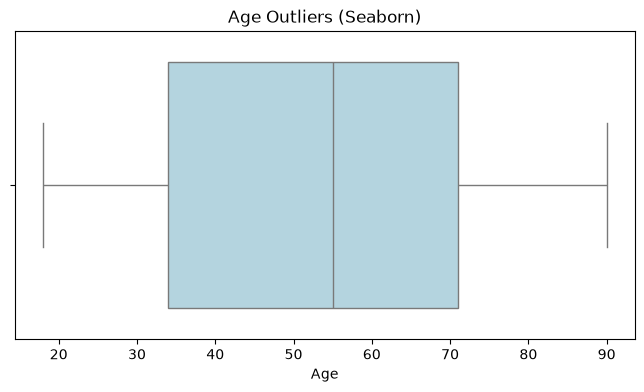

C:\Users\ala11\AppData\Local\Temp\ipykernel_34144\215670648.py:84: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['age'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))


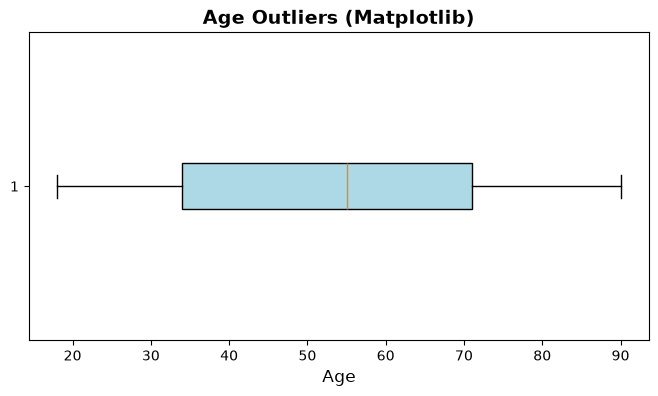

In [2]:
# 3. Data Profiling
print("DATA PROFILING")
print("="*50)

# From DataQuality (SHAPE OF DATASET)
print("\n--- Dataset Shape & Columns ---")
print("Columns in dataset:", df.columns.tolist())
num_records = df.shape[0]
num_attributes = df.shape[1]
print(f"The Dataset has {num_attributes} attributes, {num_records} instances.")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

# Basic statistics (min, max, average)
print("\n--- Descriptive Statistics (All Columns) ---")
display(df.describe(include='all').T)
print("\n--- Descriptive Statistics (Numeric Columns Only) ---")
display(df.describe()) # note here take screenshot for pdf report

# Missing values
print("\n--- Missing Values Details ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    '% Missing': missing_pct.values
}).sort_values('Missing Count', ascending=False)
display(missing_table[missing_table['Missing Count'] > 0])

print("Missing values summary (only columns with missing data):")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

# Duplicates
print("\n--- Duplicates ---")
exact_dups = df.duplicated().sum()
id_dups = df['patient_id'].duplicated().sum()
print(f"Exact duplicate rows: {exact_dups}")
print(f"Duplicate patient IDs: {id_dups}")
print(f"Total fully duplicated rows in the dataset: {exact_dups}")
print(f"Total duplicate Patient IDs: {id_dups} (important to not have duplicate in ID)")

# Validity & Inconsistency Issues
print("\n--- Validity & Inconsistency Issues ---")

# Gender
strict_genders = ['Male', 'Female']
gender_err = (~df['gender'].isin(strict_genders) & df['gender'].notnull()).sum()
print(f"Gender errors (not strictly Male/Female): {gender_err}")
print(f"Total Gender errors (violates strict 'Male'/'Female' standard): {gender_err}")

# Billing amount
numeric_billing = pd.to_numeric(df['billing_amount'], errors='coerce')
billing_non_numeric = (numeric_billing.isnull() & df['billing_amount'].notnull()).sum()
print(f"Billing amount non-numeric: {billing_non_numeric}")
print(f"Total invalid Billing Amounts (contains text/symbols): {billing_non_numeric}")

# Age range (0-120)
age_out_of_range = ((df['age'] < 0) | (df['age'] > 120)).sum()
print(f"Age out of 0-120: {age_out_of_range}")

# Appointment date format & future
appt_dates = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
appt_fmt_err = (appt_dates.isnull() & df['appointment_date'].notnull()).sum()
appt_future = (appt_dates > pd.Timestamp.today()).sum()
print(f"Appointment date format errors: {appt_fmt_err}, future dates: {appt_future}")

# Categorical columns – top values
for col in ['gender','doctor','department','follow_up_required']:
    print(f"\n--- {col} top values ---")
    print(df[col].value_counts(dropna=False).head(10))

# Outliers Plot
print("\n--- Outliers Chart (Age) ---")
# 1. Seaborn Boxplot (from IS346)
plt.figure(figsize=(8,4))
sns.boxplot(x=df['age'].dropna(), color='lightblue')
plt.title('Age Outliers (Seaborn)')
plt.xlabel('Age')
plt.show()

# 2. Matplotlib Boxplot (from DataQuality)
plt.figure(figsize=(8, 4))
plt.boxplot(df['age'].dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Age Outliers (Matplotlib)', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.gca().set_facecolor('white')
plt.show()


**Classification of Data Quality Issues**

In [3]:
followup_fail = (~df['follow_up_required'].isin(['Yes','No']) & df['follow_up_required'].notnull()).sum()
expected_depts = ['Cardiology','Neurology','Orthopedics','Pediatrics','General']
dept_fail = (~df['department'].isin(expected_depts) & df['department'].notnull()).sum()

classification_df = pd.DataFrame([
    ["Completeness", "Missing gender values", f"{df['gender'].isnull().sum()} records"],
    ["Completeness", "Missing billing_amount values", f"{df['billing_amount'].isnull().sum()} records"],
    ["Uniqueness", "Duplicate patient IDs (should be unique)", f"{df['patient_id'].duplicated().sum()} duplicates"],
    ["Validity", "Gender not 'Male'/'Female'", f"{(~df['gender'].isin(['Male','Female']) & df['gender'].notnull()).sum()} records"],
    ["Validity", "Billing amount contains text/symbols", f"{(pd.to_numeric(df['billing_amount'], errors='coerce').isnull() & df['billing_amount'].notnull()).sum()} records"],
    ["Validity", "Age outside plausible range (0-120)", f"{((df['age'] < 0) | (df['age'] > 120)).sum()} records"],
    ["Consistency", "Appointment date invalid format", f"{(pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce').isnull() & df['appointment_date'].notnull()).sum()} records"],
    ["Consistency", "Future appointment dates", f"{(pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce') > pd.Timestamp.today()).sum()} records"],
    ["Consistency", "Department values not in expected list", f"{dept_fail} records"],
    ["Consistency", "Follow-up not Yes/No", f"{followup_fail} records"]
], columns=["Category", "Issue Description", "Extent"])

print("CLASSIFICATION OF DATA QUALITY ISSUES")
print("="*70)
display(classification_df)

CLASSIFICATION OF DATA QUALITY ISSUES


,Category,Issue Description,Extent
0,Completeness,Missing gender values,50 records
1,Completeness,Missing billing_amount values,50 records
2,Uniqueness,Duplicate patient IDs (should be unique),899 duplicates
3,Validity,Gender not 'Male'/'Female',707 records
4,Validity,Billing amount contains text/symbols,950 records
5,Validity,Age outside plausible range (0-120),0 records
6,Consistency,Appointment date invalid format,908 records
7,Consistency,Future appointment dates,13 records
8,Consistency,Department values not in expected list,0 records
9,Consistency,Follow-up not Yes/No,672 records


**Quality Checks Implementation**

QUALITY CHECKS IMPLEMENTATION

Note: No email column in dataset
Total Date errors (violates DD/MM/YYYY, impossible days, or future dates) [DataQuality Calc]: 921
Quality Checks Completed on Data!

IS346 DATA QUALITY CHECK SUMMARY & CHART


,Check,Failed Records
0,Billing Format (Currency),950
1,Appt Date Invalid,921
2,Duplicate IDs,899
3,Gender Format,707
4,Follow-up Format,672
5,Missing Names,0
6,Age Range (0-120),0
7,Billing Negative,0
8,Department Format,0
9,Email Format,0


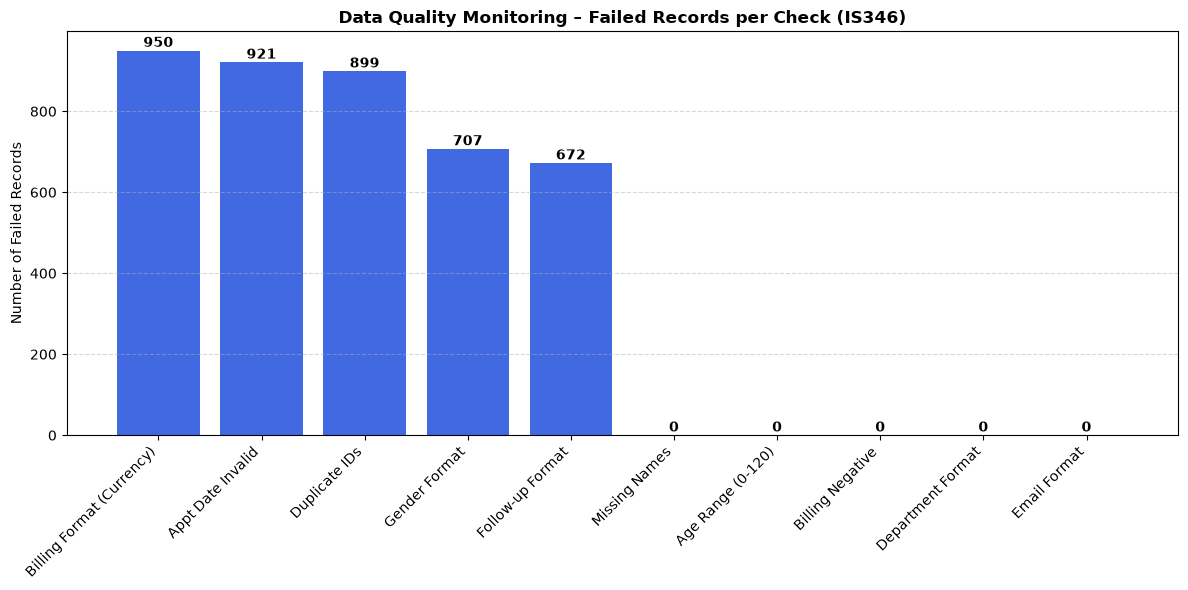


DATAQUALITY MONITORING SYSTEM CHART


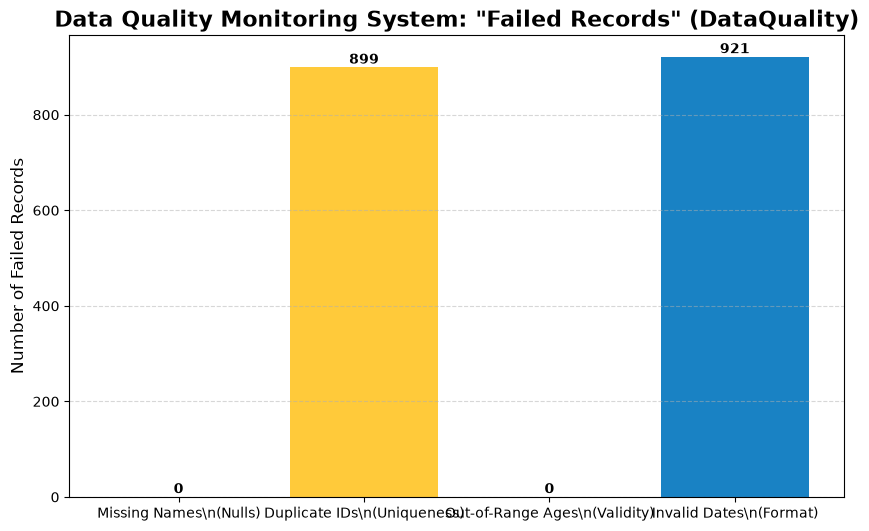

In [4]:
# 5. Quality Checks Implementation
print("QUALITY CHECKS IMPLEMENTATION")
print("="*50)

# 5.1 Completeness (Nulls)
null_counts = df.isnull().sum()
# From DataQuality
null_failures = df['patient_name'].isnull().sum()

# 5.2 Uniqueness
id_dup_count = df['patient_id'].duplicated().sum()
exact_dup_count = df.duplicated().sum()
# From DataQuality
duplicate_failures = df['patient_id'].duplicated().sum()

# 5.3 Range checks
age_range_fail = ((df['age'] < 0) | (df['age'] > 120)).sum()
# From DataQuality
range_failures = ((df['age'] < 0) | (df['age'] > 120)).sum()

billing_num = pd.to_numeric(df['billing_amount'], errors='coerce')
billing_negative = (billing_num < 0).sum()

# 5.4 Format checks (Validity / Consistency)
billing_format_fail = (pd.to_numeric(df['billing_amount'], errors='coerce').isnull() & df['billing_amount'].notnull()).sum()

gender_fail = (~df['gender'].isin(['Male','Female']) & df['gender'].notnull()).sum()

# Date Checks from IS346
appt_dt = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
date_fail = (appt_dt.isnull() & df['appointment_date'].notnull()).sum() + (appt_dt > pd.Timestamp.today()).sum()

# Date Checks from DataQuality (Strict Day/Month/Year Checks)
converted_dates = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
invalid_calendar_dates = converted_dates.isnull() & df['appointment_date'].notnull()
future_dates = converted_dates > pd.Timestamp.today()
date_failures = (invalid_calendar_dates | future_dates).sum()

followup_fail = (~df['follow_up_required'].isin(['Yes','No']) & df['follow_up_required'].notnull()).sum()

expected_departments = ['Cardiology','Neurology','Orthopedics','Pediatrics','General']
dept_fail = (~df['department'].isin(expected_departments) & df['department'].notnull()).sum()

# 5.5 Email format check (dataset has no email column)
if 'email' in df.columns:
    email_pattern = r'^[\\w\\.-]+@[\\w\\.-]+\\.[\\w]{2,}$'
    email_fail = (~df['email'].astype(str).str.match(email_pattern) & df['email'].notnull()).sum()
else:
    email_fail = 0
    print("\nNote: No email column in dataset")

print(f"Total Date errors (violates DD/MM/YYYY, impossible days, or future dates) [DataQuality Calc]: {date_failures}")
print("Quality Checks Completed on Data!")

# --- DISPLAY IS346 CHART & SUMMARY ---
print("\n" + "="*50)
print("IS346 DATA QUALITY CHECK SUMMARY & CHART")
print("="*50)

# Compile IS346 checks
failures_is346 = {
    'Missing Names': null_failures,
    'Duplicate IDs': id_dup_count,
    'Age Range (0-120)': age_range_fail,
    'Billing Negative': billing_negative,
    'Billing Format (Currency)': billing_format_fail,
    'Gender Format': gender_fail,
    'Appt Date Invalid': date_fail,
    'Follow-up Format': followup_fail,
    'Department Format': dept_fail,
    'Email Format': email_fail
}

failures_series = pd.Series(failures_is346).sort_values(ascending=False)
summary_df = pd.DataFrame({'Check': failures_series.index, 'Failed Records': failures_series.values})
display(summary_df)

# Bar chart (IS346)
plt.figure(figsize=(12,6))
bars = plt.bar(failures_series.index, failures_series.values, color='#4169E1')
plt.title('Data Quality Monitoring – Failed Records per Check (IS346)', fontweight='bold')
plt.ylabel('Number of Failed Records')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., h + 1, int(h),
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

# --- DISPLAY DATAQUALITY CHART & SUMMARY ---
print("\n" + "="*50)
print("DATAQUALITY MONITORING SYSTEM CHART")
print("="*50)

# Group the failure counts for charting
failures_dq = {
    'Missing Names\\n(Nulls)': null_failures,
    'Duplicate IDs\\n(Uniqueness)': duplicate_failures,
    'Out-of-Range Ages\\n(Validity)': range_failures,
    'Invalid Dates\\n(Format)': date_failures
}

# Create the Matplotlib Bar Chart (DataQuality)
plt.figure(figsize=(10, 6))
bars = plt.bar(failures_dq.keys(), failures_dq.values(), color=['#FF595E', '#FFCA3A', '#8AC926', '#1982C4'])

# titles and labels
plt.title('Data Quality Monitoring System: "Failed Records" (DataQuality)', fontsize=16, fontweight='bold')
plt.ylabel('Number of Failed Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add failure numbers on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold')

# background white
plt.gca().set_facecolor('white')
plt.show()


### 6. Data Quality Metrics Dashboard

Here is a summary of our data quality scores across all checked aspects (Completeness, Uniqueness, Validity, and Consistency). We calculated these scores as percentages to clearly show where the data is clean and where we have issues.

DATA QUALITY METRICS DASHBOARD

--- Detailed Metric Scores (All Quality Aspects) ---
Patient Name Completeness                : 100.00%
Gender Completeness                      : 95.00%
Billing Amount Completeness              : 95.00%
Patient ID Uniqueness                    : 10.10%
Exact Row Uniqueness                     : 100.00%
Age Range Validity (0-120)               : 100.00%
Gender Format Validity                   : 24.30%
Billing Numeric Format Validity          : 0.00%
Department List Consistency              : 100.00%
Follow-up format Consistency             : 32.80%
Appointment Date & Format Consistency    : 7.90%

--- Data Quality Dimensions Summary ---


,Quality Dimension,Score (%),Status
0,Completeness,96.67%,Excellent (>=95%)
1,Uniqueness,55.05%,Critical (<60%)
2,Validity,41.43%,Critical (<60%)
3,Consistency,46.90%,Critical (<60%)
4,Overall Quality Score,60.01%,Needs Attention (>=60%)


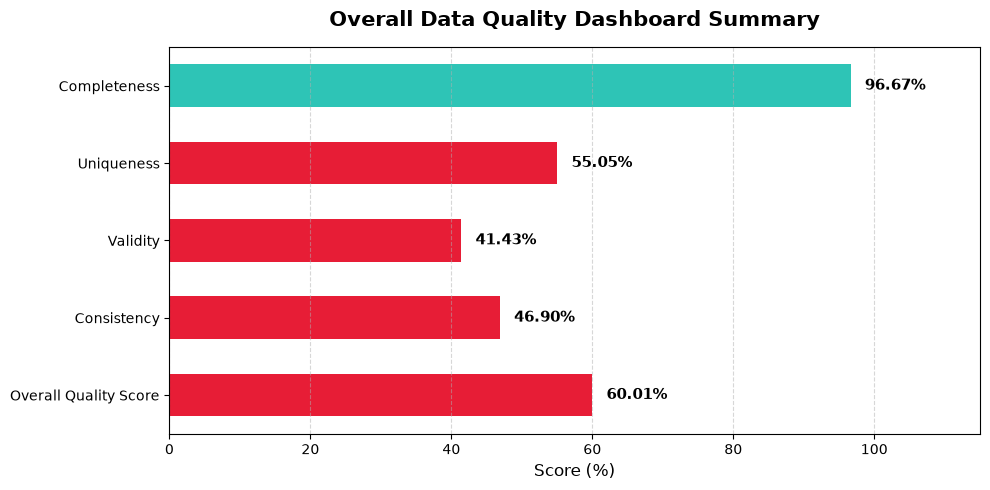

In [5]:
# 6. Data Quality Metrics Dashboard
print("DATA QUALITY METRICS DASHBOARD")
print("="*50)

total_records = len(df)

# --- 1. Completeness Score (Percentage of non-null values) ---
name_comp = (df['patient_name'].notnull().sum() / total_records) * 100
gender_comp = (df['gender'].notnull().sum() / total_records) * 100
billing_comp = (df['billing_amount'].notnull().sum() / total_records) * 100
completeness_score = (name_comp + gender_comp + billing_comp) / 3

# --- 2. Uniqueness Score (Percentage of unique values) ---
patient_id_uniq = ((total_records - df['patient_id'].duplicated().sum()) / total_records) * 100
exact_row_uniq = ((total_records - df.duplicated().sum()) / total_records) * 100
uniqueness_score = (patient_id_uniq + exact_row_uniq) / 2

# --- 3. Validity Score (Compliance with constraints) ---
valid_age = (100 - (((df['age'] < 0) | (df['age'] > 120)).sum() / total_records * 100))
valid_gender = (df['gender'].isin(['Male', 'Female']).sum() / total_records) * 100
valid_billing = (pd.to_numeric(df['billing_amount'], errors='coerce').notnull().sum() / total_records) * 100
validity_score = (valid_age + valid_gender + valid_billing) / 3

# --- 4. Consistency Score (Adherence to logic & standard values) ---
expected_depts = ['Cardiology', 'Neurology', 'Orthopedics', 'Pediatrics', 'General']
valid_dept = (df['department'].isin(expected_depts).sum() / total_records) * 100
valid_followup = (df['follow_up_required'].isin(['Yes', 'No']).sum() / total_records) * 100

# Calendar check for valid formatting and past/current dates only
appt_dt = pd.to_datetime(df['appointment_date'], format='%d/%m/%Y', errors='coerce')
valid_dates_count = (appt_dt.notnull() & (appt_dt <= pd.Timestamp.today())).sum()
valid_date = (valid_dates_count / total_records) * 100
consistency_score = (valid_dept + valid_followup + valid_date) / 3

# --- 5. Overall Quality score ---
overall_score = (completeness_score + uniqueness_score + validity_score + consistency_score) / 4

# Print Detailed Results for All Aspects
print("\n--- Detailed Metric Scores (All Quality Aspects) ---")
print(f"{"Patient Name Completeness":40s} : {name_comp:.2f}%")
print(f"{"Gender Completeness":40s} : {gender_comp:.2f}%")
print(f"{"Billing Amount Completeness":40s} : {billing_comp:.2f}%")
print(f"{"Patient ID Uniqueness":40s} : {patient_id_uniq:.2f}%")
print(f"{"Exact Row Uniqueness":40s} : {exact_row_uniq:.2f}%")
print(f"{"Age Range Validity (0-120)":40s} : {valid_age:.2f}%")
print(f"{"Gender Format Validity":40s} : {valid_gender:.2f}%")
print(f"{"Billing Numeric Format Validity":40s} : {valid_billing:.2f}%")
print(f"{"Department List Consistency":40s} : {valid_dept:.2f}%")
print(f"{"Follow-up format Consistency":40s} : {valid_followup:.2f}%")
print(f"{"Appointment Date & Format Consistency":40s} : {valid_date:.2f}%")

# Display Dimension Summary Table
print("\n--- Data Quality Dimensions Summary ---")
summary_metrics = {
    'Completeness': completeness_score,
    'Uniqueness': uniqueness_score,
    'Validity': validity_score,
    'Consistency': consistency_score,
    'Overall Quality Score': overall_score
}
metrics_df = pd.DataFrame({
    'Quality Dimension': list(summary_metrics.keys()),
    'Score (%)': [f"{val:.2f}%" for val in summary_metrics.values()],
    'Status': ['Excellent (>=95%)' if val >= 95 else 'Good (>=85%)' if val >= 85 else 'Needs Attention (>=60%)' if val >= 60 else 'Critical (<60%)' for val in summary_metrics.values()]
})
display(metrics_df)

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 5))
colors = ['#2EC4B6' if val >= 90 else '#FF9F1C' if val >= 70 else '#E71D36' for val in summary_metrics.values()]
bars = plt.barh(list(summary_metrics.keys()), list(summary_metrics.values()), color=colors, height=0.55)

plt.xlim(0, 115)
plt.title('Overall Data Quality Dashboard Summary', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Score (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add value tags to the right of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2, f"{width:.2f}%",
             ha='left', va='center', fontweight='bold', fontsize=11)

plt.gca().invert_yaxis()
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()
